In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from src.metrics import dice_coef
from src.graphs import make_row_aurc, corruption_level
from src.confidence import (SoftDice, MeanMaxConfidence,ExpectedEntropy,Median_min_max,Quantile_thresh, Patch_Level_Aggregation)
from src.utils import plot_aurc_curves, adjust_axis_limits, thresh_alpha
import scienceplots
import pickle
from matplotlib.ticker import FuncFormatter

 Parameters used to construct the graphics in the paper.

In [ ]:
plt.style.use(['science'])
plt.rcParams['image.cmap'] = 'bwr'
#plt.rcParams['axes.grid'] = True
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (3.0, 2.625)
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.facecolor'] = 'white'
plt.rcParams['legend.framealpha'] = 1
plt.rcParams['legend.edgecolor'] = 'white'
plt.rcParams.update({'font.size': 9})
colors = [plt.colormaps['tab20'](i) for i in range(20)]

markersize = 3
styles = dict(
random=dict(linestyle='--', color='gray', label="Random"),
amsp=dict(color=colors[0], markersize=markersize, marker="v"),
ane=dict(color=colors[1], markersize=markersize, marker="p"),
mmmc=dict(color=colors[2], markersize=markersize, marker="D"),
tla=dict(color=colors[3], markersize=markersize, marker="^"),
pll=dict(color=colors[4], markersize=markersize, marker="o"),
sdc=dict(color=colors[5], markersize=markersize, marker="s"),
aef=dict(color=colors[6], markersize=markersize, marker="*"),
aef_sdc=dict(color=colors[7], markersize=markersize, marker="h"),
oracle=dict(linestyle=':',color='gray', markersize=markersize, label="Oracle"),
idc_true=dict(color=colors[9], marker="*", zorder=-2),
idc_hat=dict(color=colors[10], markersize=markersize+2, marker=".", zorder=-1),
)

In [6]:
def format_func(value, _):
    return f"{value:.2f}"

# MSWML-OOD RC curve

In [ ]:
# MSWML have predictions with different shapes
with open('./data/mswml/dev_out_predictions.pkl', 'rb') as f:
    p_hat = pickle.load(f)

with open('./data/mswml/dev_out_gt.pkl', 'rb') as f:
    y = pickle.load(f)

25
25


Recovering ID AURC with 100% Coverage

In [8]:
with open('aurcs_data.pkl', "rb") as file:
    aurcs_all = pickle.load(file)

Global variables to construct tables

In [ ]:
all_corruptions = {}
all_aurcs = {}
prevails = {}

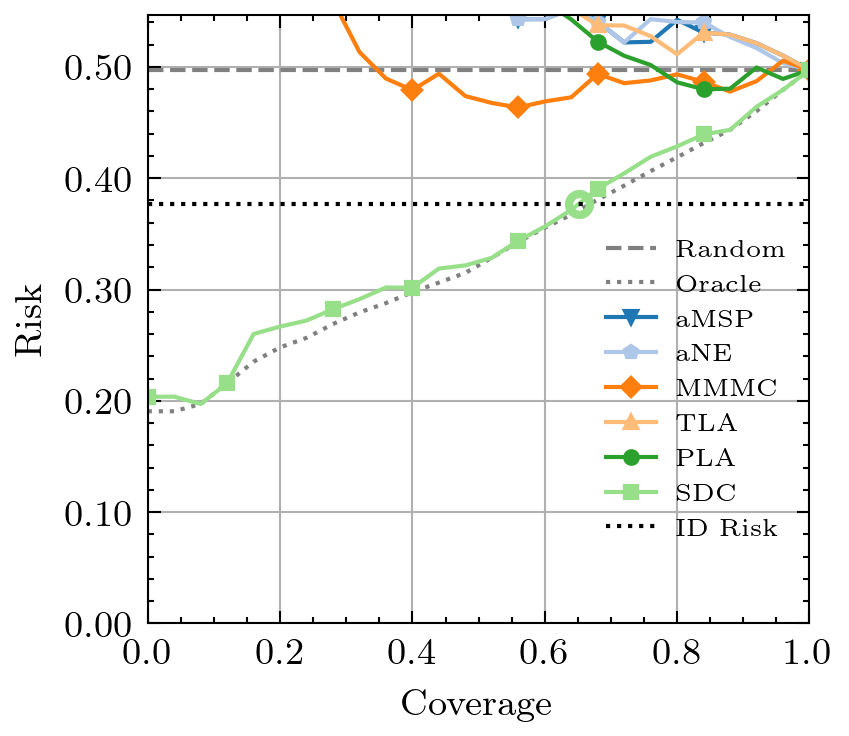

In [ ]:
task = 'mswml'
tresh =0.35
threshold_alpha = thresh_alpha(p_hat, threshold = tresh)

confidence_metrics = {
    'aMSP': MeanMaxConfidence(),
    'aNE': ExpectedEntropy(),
    'MMMC':Median_min_max(),
    'TLA':Quantile_thresh(threshold_alpha),
    'PLA':Patch_Level_Aggregation(),
    'SDC': SoftDice(tresh),
#    'SoftDice_PLL':SoftDice_PLL(threshold_lim= tresh, alpha=best_alpha),
}
confidences = {name: [confidence_metric(p_hat_i) for p_hat_i in p_hat]
               for name, confidence_metric in confidence_metrics.items()}

dice_scores = np.stack([dice_coef(p_hat[i], y[i],threshold=tresh) for i in range(len(y))])
dice_errors = 1 - dice_scores

fig, ax = plt.subplots()
ax = plot_aurc_curves(confidences, dice_errors, ax)
#ax = plot_max_aurc_curves(confidences, dice_errors, ax)
y_min, y_max = adjust_axis_limits(np.mean(dice_errors))

ax.set_ylim(y_min, y_max)
#ax.set_ylim(0,np.max(dice_errors)*1.2)


# Draw the horizontal dashed line
id_risk = aurcs_all[task]['Random']
ax.axhline(y=id_risk, linestyle=':', color='black', label='ID Risk')

# Retrieve all plotted lines (curves) on the axes.
lines = ax.get_lines()

# For each curve, find where it crosses the horizontal line and mark only the rightmost intersection.
for line in lines:
    if line.get_label() != 'Oracle':
        xdata = np.array(line.get_xdata())
        ydata = np.array(line.get_ydata())

        diff = ydata - id_risk
        crossing_indices = np.where(np.diff(np.sign(diff)))[0]

        x_intersects = []
        for i in crossing_indices:
            x0, x1 = xdata[i], xdata[i+1]
            y0, y1 = ydata[i], ydata[i+1]
            if y1 == y0:
                continue
            t = (id_risk - y0) / (y1 - y0)
            x_intersect = x0 + t * (x1 - x0)
            x_intersects.append(x_intersect)

        if x_intersects:  # only if we found intersections
            max_x = max(x_intersects)
            ax.plot(
                max_x, id_risk,
                marker='o', markerfacecolor='none',
                markersize=5, markeredgewidth=2,
                color=line.get_color()
            )
            
#ax.set_title('%s'%name)
#ax.legend(loc='lower right')
#ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)
ax.legend(loc='lower right', ncol=1, frameon=False, bbox_to_anchor=(1.0, 0.1))
#ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('Risk')
ax.set_xlabel('Coverage')
#fig.set_size_inches(4.5,3.25)
#fig.savefig('../%s/%s.pdf'%(dir_path_save,name), dpi=dpi)
ax.yaxis.set_major_formatter(FuncFormatter(format_func))
fig.tight_layout()
fig.savefig("./graphs/MSWML - UNET Ensemble model - Out Dist.pdf", format="pdf")
fig.show()

In [ ]:
task = 'mswml'
error_base = aurcs_all[task]['Random']
name='MSWML - UNET Ensemble model - Out Dist'
#make_fig_aurc(y=y, y_hat=y_hat,dir_path_save='Thesis_Aditional_Graphs',  name=name,dpi=50,threshold=0.35, soft_thres=0.35, metric='dice') 
all_aurcs[name] = make_row_aurc(y=y, y_hat=p_hat, threshold = 0.35,soft_thres=0.35, metric='dice')
all_corruptions[name] = corruption_level(y=y, y_hat=p_hat, error_base=error_base,threshold = 0.35, metric='dice')

In [16]:
prevail = []
for y_i in y:
    prevail.append(np.mean(y_i.squeeze()))
prevails['mswml'] = np.mean(prevail)

# Polyp-OOD RC curve

In [ ]:
data = np.load('./data/polyp_pvt_ood.npz')

y = data['y']
p_hat = data['p_hat']

zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

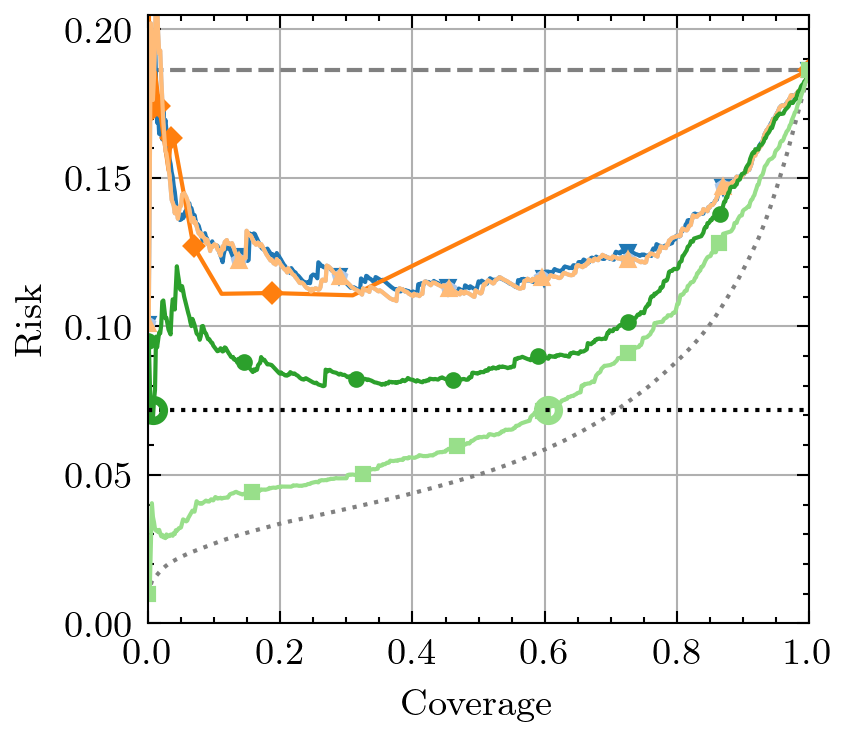

In [ ]:
tresh =0.5
threshold_alpha = thresh_alpha(p_hat, threshold = tresh)
task = 'polyp-pvt'
confidence_metrics = {
    'aMSP': MeanMaxConfidence(),
    'aNE': ExpectedEntropy(),
    'MMMC':Median_min_max(),
    'TLA':Quantile_thresh(threshold_alpha),
    'PLA':Patch_Level_Aggregation(),
    'SDC': SoftDice(tresh),
#    'SoftDice_PLL':SoftDice_PLL(threshold_lim= tresh, alpha=best_alpha),
}
confidences = {name: [confidence_metric(p_hat_i) for p_hat_i in p_hat]
               for name, confidence_metric in confidence_metrics.items()}

dice_scores = np.stack([dice_coef(p_hat[i], y[i],threshold=tresh) for i in range(len(y))])
dice_errors = 1 - dice_scores

fig, ax = plt.subplots()
ax = plot_aurc_curves(confidences, dice_errors, ax)
#ax = plot_max_aurc_curves(confidences, dice_errors, ax)
y_min, y_max = adjust_axis_limits(np.mean(dice_errors))

ax.set_ylim(y_min, y_max)
# Draw the horizontal dashed line
id_risk = aurcs_all[task]['Random']
ax.axhline(y=id_risk, linestyle=':', color='black', label='ID Risk')

# Retrieve all plotted lines (curves) on the axes.
lines = ax.get_lines()

# For each curve, find where it crosses the horizontal line and mark only the rightmost intersection.
for line in lines:
    if line.get_label() != 'Oracle':
        xdata = np.array(line.get_xdata())
        ydata = np.array(line.get_ydata())

        diff = ydata - id_risk
        crossing_indices = np.where(np.diff(np.sign(diff)))[0]

        x_intersects = []
        for i in crossing_indices:
            x0, x1 = xdata[i], xdata[i+1]
            y0, y1 = ydata[i], ydata[i+1]
            if y1 == y0:
                continue
            t = (id_risk - y0) / (y1 - y0)
            x_intersect = x0 + t * (x1 - x0)
            x_intersects.append(x_intersect)

        if x_intersects:  # only if we found intersections
            max_x = max(x_intersects)
            ax.plot(
                max_x, id_risk,
                marker='o', markerfacecolor='none',
                markersize=5, markeredgewidth=2,
                color=line.get_color()
            )

#ax.set_title('%s'%name)
#ax.legend(loc='lower right')
#ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)
#ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('Risk')
ax.set_xlabel('Coverage')
#fig.set_size_inches(4.5,3.25)
#fig.savefig('../%s/%s.pdf'%(dir_path_save,name), dpi=dpi)
plt.legend().set_visible(False)
ax.yaxis.set_major_formatter(FuncFormatter(format_func))
fig.tight_layout()
fig.savefig("./graphs/Polyp - PVT model - Out Dist.pdf", format="pdf")
fig.show()

In [ ]:
task = 'polyp-pvt'
error_base = aurcs_all[task]['Random']
name='Polyp - PVT model - Out Dist'
#make_fig_aurc(y=y, y_hat=y_hat,dir_path_save='Thesis_Aditional_Graphs',  name=name,dpi=50,threshold=0.5, soft_thres=0.5, metric='dice') 
all_aurcs[name] = make_row_aurc(y=y, y_hat=p_hat, threshold = 0.5,soft_thres=0.5, metric='dice')
all_corruptions[name] = corruption_level(y=y, y_hat=p_hat, error_base=error_base,threshold = 0.5, metric='dice')

In [25]:
prevail = []
for y_i in y:
    prevail.append(np.mean(y_i.squeeze()))
prevails['polyp-pvt'] = np.mean(prevail)

# Optic Cup-OOD RC curve

In [ ]:
data = np.load('./data/optic_cup_ood.npz')

y = data['y']
p_hat = data['p_hat']

zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

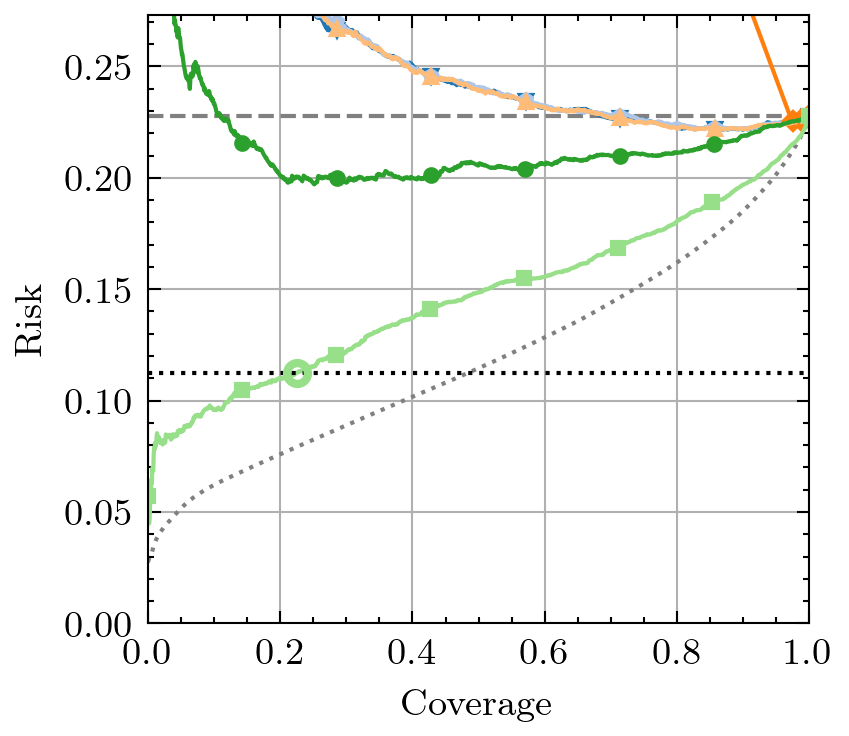

In [ ]:
tresh =0.5
threshold_alpha = thresh_alpha(p_hat, threshold = tresh)
task = 'refuge'
confidence_metrics = {
    'aMSP': MeanMaxConfidence(),
    'aNE': ExpectedEntropy(),
    'MMMC':Median_min_max(),
    'TLA':Quantile_thresh(threshold_alpha),
    'PLA':Patch_Level_Aggregation(),
    'SDC': SoftDice(tresh),
#    'SoftDice_PLL':SoftDice_PLL(threshold_lim= tresh, alpha=best_alpha),
}
confidences = {name: [confidence_metric(p_hat_i) for p_hat_i in p_hat]
               for name, confidence_metric in confidence_metrics.items()}

dice_scores = np.stack([dice_coef(p_hat[i], y[i],threshold=tresh) for i in range(len(y))])
dice_errors = 1 - dice_scores

fig, ax = plt.subplots()
ax = plot_aurc_curves(confidences, dice_errors, ax)
#ax = plot_max_aurc_curves(confidences, dice_errors, ax)
ax.set_ylim(0,np.mean(dice_errors)*1.2)
# Draw the horizontal dashed line
id_risk = aurcs_all[task]['Random']
ax.axhline(y=id_risk, linestyle=':', color='black', label='ID Risk')

# Retrieve all plotted lines (curves) on the axes.
lines = ax.get_lines()

# For each curve, find where it crosses the horizontal line and mark only the rightmost intersection.
for line in lines:
    if line.get_label() != 'Oracle':
        xdata = np.array(line.get_xdata())
        ydata = np.array(line.get_ydata())

        diff = ydata - id_risk
        crossing_indices = np.where(np.diff(np.sign(diff)))[0]

        x_intersects = []
        for i in crossing_indices:
            x0, x1 = xdata[i], xdata[i+1]
            y0, y1 = ydata[i], ydata[i+1]
            if y1 == y0:
                continue
            t = (id_risk - y0) / (y1 - y0)
            x_intersect = x0 + t * (x1 - x0)
            x_intersects.append(x_intersect)

        if x_intersects:  # only if we found intersections
            max_x = max(x_intersects)
            ax.plot(
                max_x, id_risk,
                marker='o', markerfacecolor='none',
                markersize=5, markeredgewidth=2,
                color=line.get_color()
            )

#ax.set_title('%s'%name)
#ax.legend(loc='lower right')
#ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)
#ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('Risk')
ax.set_xlabel('Coverage')
#fig.set_size_inches(4.5,3.25)
#fig.savefig('../%s/%s.pdf'%(dir_path_save,name), dpi=dpi)
plt.legend().set_visible(False)
ax.yaxis.set_major_formatter(FuncFormatter(format_func))
fig.tight_layout()
fig.savefig("./graphs/Optic Cup - Segtran model - Out Dist.pdf", format="pdf")
fig.show()

In [28]:
task = 'refuge'
error_base = aurcs_all[task]['Random']
name='Optic Cup - Segtran model - Out Dist'
#make_fig_aurc(y=y, y_hat=y_hat,dir_path_save='Thesis_Aditional_Graphs',  name=name,dpi=50,threshold=0.5, soft_thres=0.5, metric='dice') 
all_aurcs[name] = make_row_aurc(y=y, y_hat=y_hat, threshold = 0.5,soft_thres=0.5, metric='dice')
all_corruptions[name] = corruption_level(y=y, y_hat=y_hat, error_base=error_base,threshold = 0.5, metric='dice')

In [29]:
prevail = []
for y_i in y:
    prevail.append(np.mean(y_i.squeeze()))
prevails['optic-cup'] = np.mean(prevail)

# Tables creation

In [30]:
import pandas as pd

def dataframe_to_latex(df, caption, label, index):
    """
    Convert a pandas DataFrame to a LaTeX tabular string with numeric values rounded to 4 decimal places.

    Parameters:
        df (pd.DataFrame): The DataFrame to convert.

    Returns:
        str: A string containing the LaTeX table.
    """
    latex_table = "\\begin{table}[ht]\n"
    latex_table += "\\centering\n"
    latex_table += "\\begin{tabular}{" + " | ".join(["c"] * (len(df.columns) + 1)) + "}\n"
    latex_table += "\\hline\n"

    # Add column headers, including the index
    latex_table += "%s & "%index + " & ".join(df.columns) + " \\\\\n"
    latex_table += "\\hline\n"

    # Add rows with formatting
    for idx, row in df.iterrows():
        formatted_row = [
            str(idx)
        ] + [
            f"{x:.4f}" if isinstance(x, (int, float)) else str(x) for x in row.values
        ]
        latex_table += " & ".join(formatted_row) + " \\\\\n"
        latex_table += "\\hline\n"

    latex_table += "\\end{tabular}\n"
    latex_table += "\\caption{%s}\n" %caption
    latex_table += "\\label{tab:%s}\n" %label
    latex_table += "\\end{table}\n"

    return latex_table

In [31]:
def dataframe_to_latex(df, caption, label, index):
    """
    Convert a pandas DataFrame to a transposed LaTeX tabular string with numeric values rounded to 4 decimal places.

    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        caption (str): Caption for the table.
        label (str): Label for the table.
        index (str): Header label for the first column (which now contains the original column names).

    Returns:
        str: A string containing the LaTeX table.
    """
    # Transpose the DataFrame so that rows become columns and vice versa.
    df = df.transpose()[['Random', 'aMSP', 'aNE', 'MMMC', 'TLA', 'PLA','SDC', 'Ideal']]
    df = df.transpose()

    latex_table = "\\begin{table}[ht]\n"
    latex_table += "\\centering\n"
    # There is one extra column for the row labels.
    latex_table += "\\begin{tabular}{" + " | ".join(["c"] * (len(df.columns) + 1)) + "}\n"
    latex_table += "\\hline\n"

    # The header row: the first cell is the provided label, then the column headers
    # (which are now the original DataFrame's index values).
    latex_table += f"{index} & " + " & ".join(str(col) for col in df.columns) + " \\\\\n"
    latex_table += "\\hline\n"

    # Iterate over the transposed rows (which correspond to the original DataFrame's columns)
    for idx, row in df.iterrows():
        # The first cell is the row header (the original column name)
        formatted_row = [str(idx)]
        # Format each cell: if numeric, round to 4 decimals; otherwise, use its string representation.
        formatted_row.extend(
            f"{x:.3f}" if isinstance(x, (int, float)) else str(x)
            for x in row.values
        )
        latex_table += " & ".join(formatted_row) + " \\\\\n"
        latex_table += "\\hline\n"

    latex_table += "\\end{tabular}\n"
    latex_table += "\\caption{" + caption + "}\n"
    latex_table += "\\label{tab:" + label + "}\n"
    latex_table += "\\end{table}\n"

    return latex_table

In [32]:
print(dataframe_to_latex(pd.DataFrame(all_aurcs), caption='AURCS of OOD data for non trainable confidence estimators', label='aurcs_ood_table', index= 'Confidence estimator'))

\begin{table}[ht]
\centering
\begin{tabular}{c | c | c | c}
\hline
Confidence estimator & MSWML - UNET Ensemble model - Out Dist & Polyp - PVT model - Out Dist & Optic Cup - Segtran model - Out Dist \\
\hline
Random & 0.497 & 0.186 & 0.228 \\
\hline
aMSP & 0.600 & 0.129 & 0.270 \\
\hline
aNE & 0.595 & 0.128 & 0.268 \\
\hline
MMMC & 0.544 & 0.141 & 0.605 \\
\hline
TLA & 0.612 & 0.128 & 0.268 \\
\hline
PLA & 0.603 & 0.103 & 0.220 \\
\hline
SDC & 0.338 & 0.076 & 0.146 \\
\hline
Ideal & 0.330 & 0.062 & 0.119 \\
\hline
\end{tabular}
\caption{AURCS of OOD data for non trainable confidence estimators}
\label{tab:aurcs_ood_table}
\end{table}



In [33]:
def dataframe_to_latex(df, caption, label, index):
    """
    Convert a pandas DataFrame to a LaTeX tabular string with numeric values rounded to 4 decimal places.

    Parameters:
        df (pd.DataFrame): The DataFrame to convert.

    Returns:
        str: A string containing the LaTeX table.
    """
    latex_table = "\\begin{table}[ht]\n"
    latex_table += "\\centering\n"
    latex_table += "\\begin{tabular}{" + " | ".join(["c"] * (len(df.columns) + 1)) + "}\n"
    latex_table += "\\hline\n"

    # Add column headers, including the index
    latex_table += "%s & "%index + " & ".join(df.columns) + " \\\\\n"
    latex_table += "\\hline\n"

    # Add rows with formatting
    for idx, row in df.iterrows():
        formatted_row = [
            str(idx)
        ] + [
            f"{x:.2f}" if isinstance(x, (int, float)) else str(x) for x in row.values
        ]
        latex_table += " & ".join(formatted_row) + " \\\\\n"
        latex_table += "\\hline\n"

    latex_table += "\\end{tabular}\n"
    latex_table += "\\caption{%s}\n" %caption
    latex_table += "\\label{tab:%s}\n" %label
    latex_table += "\\end{table}\n"

    return latex_table

In [36]:
def dataframe_to_latex(df, caption, label, index):
    """
    Convert a pandas DataFrame to a transposed LaTeX tabular string with numeric values rounded to 2 decimal places.

    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        caption (str): Caption for the table.
        label (str): Label for the table.
        index (str): Header label for the first column (which now contains the original column names).

    Returns:
        str: A string containing the LaTeX table.
    """
    # Transpose the DataFrame so that rows become columns and vice versa.
    df = df.transpose()[['aMSP', 'aNE', 'MMMC', 'TLA', 'PLA' ,'SDC','Ideal']]
    df = df.transpose()
    
    latex_table = "\\begin{table}[ht]\n"
    latex_table += "\\centering\n"
    # One extra column for the row labels.
    latex_table += "\\begin{tabular}{" + " | ".join(["c"] * (len(df.columns) + 1)) + "}\n"
    latex_table += "\\hline\n"

    # Add the header row: the first cell is the provided index label, 
    # followed by the new column headers (the original DataFrame's index).
    latex_table += f"{index} & " + " & ".join(str(col) for col in df.columns) + " \\\\\n"
    latex_table += "\\hline\n"
 
    # Add the table rows, where each row corresponds to one of the original DataFrame's columns.
    for idx, row in df.iterrows():
        formatted_row = [str(idx)] + [
            f"{x:.2f}" if isinstance(x, (int, float)) else str(x)
            for x in row.values
        ]
        latex_table += " & ".join(formatted_row) + " \\\\\n"
        latex_table += "\\hline\n"

    latex_table += "\\end{tabular}\n"
    latex_table += "\\caption{" + caption + "}\n"
    latex_table += "\\label{tab:" + label + "}\n"
    latex_table += "\\end{table}\n"

    return latex_table

In [37]:
print(dataframe_to_latex(pd.DataFrame(all_corruptions), caption='Corruption Level for Each Confidence Estimator', label='corruption_table', index= 'Confidence estimator'))

\begin{table}[ht]
\centering
\begin{tabular}{c | c | c | c}
\hline
Confidence estimator & MSWML - UNET Ensemble model - Out Dist & Polyp - PVT model - Out Dist & Optic Cup - Segtran model - Out Dist \\
\hline
aMSP & - & - & - \\
\hline
aNE & - & - & - \\
\hline
MMMC & - & - & - \\
\hline
TLA & - & - & - \\
\hline
PLA & - & 0.79 & - \\
\hline
SDC & 64.00 & 60.53 & 22.45 \\
\hline
Ideal & 64.00 & 70.90 & 48.50 \\
\hline
\end{tabular}
\caption{Corruption Level for Each Confidence Estimator}
\label{tab:corruption_table}
\end{table}



In [38]:
prevails

{'mswml': 0.0019102325,
 'polyp-pvt': 0.061620794268802945,
 'optic-cup': 0.10511133871799277}

In [39]:
with open('aurcs_data_OOD.pkl', "wb") as file:
    pickle.dump(all_aurcs, file)

In [40]:
all_aurcs

{'MSWML - UNET Ensemble model - Out Dist': {'Random': 0.49741475914721833,
  'Ideal': 0.3300233607601534,
  'aMSP': 0.60030352610468,
  'aNE': 0.5953552805883301,
  'MMMC': 0.5437447203860966,
  'TLA': 0.6120949545006544,
  'PLA': 0.603248563482564,
  'SDC': 0.3381349200532905},
 'Polyp - PVT model - Out Dist': {'Random': 0.18639790517549149,
  'Ideal': 0.062340268913541566,
  'aMSP': 0.12905057412379053,
  'aNE': 0.1283696549939447,
  'MMMC': 0.1405849086483583,
  'TLA': 0.12837504139093672,
  'PLA': 0.10266389815837128,
  'SDC': 0.07612018945417526},
 'Optic Cup - Segtran model - Out Dist': {'Random': 0.22776078354090062,
  'Ideal': 0.11906813359944379,
  'aMSP': 0.2699444153551369,
  'aNE': 0.26802865301664885,
  'MMMC': 0.6046399517437807,
  'TLA': 0.2684321524346946,
  'PLA': 0.21998778023102383,
  'SDC': 0.1464516724922425}}